# 02 — Feature Engineering
### PMSM Winding Process — Quality Prediction Project
---
**Goal:** Transform raw data into a modelling-ready feature matrix.  
Steps: derived feature creation → encoding → scaling → validation → save processed datasets.


## 1. Imports & Config

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('02_FeatureEngineering.ipynb')))
print("Working directory:", os.getcwd())

Working directory: d:\Downloads\PMSM Winding Project\pmsm-winding-quality-prediction\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 12,
})

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


## 2. Load Raw Data

In [3]:
df = pd.read_csv('../data/raw/pmsm_winding_process_data.csv')
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
df.head(3)


Loaded: 500 rows × 30 cols


,sample_id,winding_speed_rpm,wire_tension_N,wire_diameter_mm,num_turns,slot_width_mm,slot_depth_mm,insulation_thickness_mm,winding_temperature_C,spindle_torque_Nm,...,power_rms_W,power_energy_J,temp_max_C,temp_gradient_C_per_turn,temp_time_above_60s,slot_fill_factor_pct,winding_resistance_mOhm,insulation_integrity_score,insulation_failure,process_stability_index
0,PMSM_0001,424.7,18.96,1.00,47,6.13,19.15,0.035,26.0,1.186,...,52.88,350.38,29.4,0.0703,0.000,30.72,263.8,65.6,0,0.9448
1,PMSM_0002,770.4,15.72,0.71,82,5.23,29.57,0.078,42.6,2.934,...,231.26,1511.85,53.2,0.1282,0.000,22.00,890.4,64.7,0,0.9574
2,PMSM_0003,639.2,11.19,1.12,115,5.15,19.97,0.032,64.6,2.517,...,173.12,1818.51,70.3,0.0493,7.509,82.00,517.7,57.0,0,0.9824


In [ ]:
# Column groups
PROCESS_PARAMS = [
    'winding_speed_rpm', 'wire_tension_N', 'wire_diameter_mm', 'num_turns',
    'slot_width_mm', 'slot_depth_mm', 'insulation_thickness_mm',
    'winding_temperature_C', 'spindle_torque_Nm', 'back_tension_N'
]
TENSION_FEATURES = ['tension_mean_N', 'tension_std_N', 'tension_peak_N',
                    'tension_slope_start', 'tension_area_Nmm']
POWER_FEATURES   = ['power_mean_W', 'power_std_W', 'power_peak_W',
                    'power_rms_W', 'power_energy_J']
TEMP_FEATURES    = ['temp_max_C', 'temp_gradient_C_per_turn', 'temp_time_above_60s']

ALL_RAW_FEATURES = PROCESS_PARAMS + TENSION_FEATURES + POWER_FEATURES + TEMP_FEATURES

TARGETS_REG = ['slot_fill_factor_pct', 'winding_resistance_mOhm',
               'insulation_integrity_score', 'process_stability_index']
TARGET_CLF  = 'insulation_failure'
TARGETS_ALL = TARGETS_REG + [TARGET_CLF]
print(f"Raw feature count: {len(ALL_RAW_FEATURES)}")


Raw feature count: 23


## 3. Derived Feature Engineering
We create **9 new features** motivated by physical process knowledge.  
Each feature captures a meaningful interaction or ratio between existing signals.


In [5]:
fe = df.copy()

# ── 3.1 Tension variability ratio ─────────────────────────────────────────
# High variability relative to mean → loose / inconsistent winding
fe['tension_variability_ratio'] = fe['tension_std_N'] / (fe['tension_mean_N'] + 1e-6)

# ── 3.2 Tension dynamic range ─────────────────────────────────────────────
# Difference between peak and mean — captures tension spikes
fe['tension_dynamic_range'] = fe['tension_peak_N'] - fe['tension_mean_N']

# ── 3.3 Power per turn ────────────────────────────────────────────────────
# Normalises spindle energy by number of turns → effort per turn
fe['power_per_turn_W'] = fe['power_mean_W'] / (fe['num_turns'] + 1e-6)

# ── 3.4 Power instability index ───────────────────────────────────────────
# Similar to tension variability but for spindle power
fe['power_instability_idx'] = fe['power_std_W'] / (fe['power_mean_W'] + 1e-6)

# ── 3.5 Thermal stress index ──────────────────────────────────────────────
# Combines peak temperature and gradient → insulation stress proxy
fe['thermal_stress_idx'] = fe['temp_max_C'] * fe['temp_gradient_C_per_turn']

# ── 3.6 Slot density index ────────────────────────────────────────────────
# How densely packed is the slot in theory (pre-process prediction)
slot_area = fe['slot_width_mm'] * fe['slot_depth_mm']
wire_cs   = np.pi * (fe['wire_diameter_mm'] / 2.0) ** 2
fe['slot_density_idx'] = (fe['num_turns'] * wire_cs) / (slot_area + 1e-6)

# ── 3.7 Mechanical load index ─────────────────────────────────────────────
# Combined tension and torque load on the wire
fe['mech_load_idx'] = fe['wire_tension_N'] * fe['spindle_torque_Nm']

# ── 3.8 Speed-tension interaction ─────────────────────────────────────────
# Fast + high tension can over-stress insulation
fe['speed_tension_product'] = fe['winding_speed_rpm'] * fe['wire_tension_N']

# ── 3.9 Effective back-tension ratio ──────────────────────────────────────
# How much the back tension compensates the main wire tension
fe['back_tension_ratio'] = fe['back_tension_N'] / (fe['wire_tension_N'] + 1e-6)

DERIVED_FEATURES = [
    'tension_variability_ratio', 'tension_dynamic_range',
    'power_per_turn_W', 'power_instability_idx',
    'thermal_stress_idx', 'slot_density_idx',
    'mech_load_idx', 'speed_tension_product', 'back_tension_ratio'
]
print(f"Derived features created: {len(DERIVED_FEATURES)}")
print(fe[DERIVED_FEATURES].describe().round(4).to_string())


Derived features created: 9
       tension_variability_ratio  tension_dynamic_range  power_per_turn_W  power_instability_idx  thermal_stress_idx  slot_density_idx  mech_load_idx  speed_tension_product  back_tension_ratio
count                   500.0000               500.0000          500.0000               500.0000            500.0000          500.0000       500.0000               500.0000            500.0000
mean                      0.0986                 2.9984            1.9092                 0.0741              6.7986            0.3915        38.5300              7317.4696              0.3654
std                       0.0599                 1.1804            1.3229                 0.0259              4.5706            0.3555        23.2520              3973.1405              0.2502
min                       0.0044                 1.0060            0.2204                 0.0300              0.4641            0.0226         4.8330              1170.0660              0.0451
25%    

### 3.1 Visualise Derived Feature Distributions

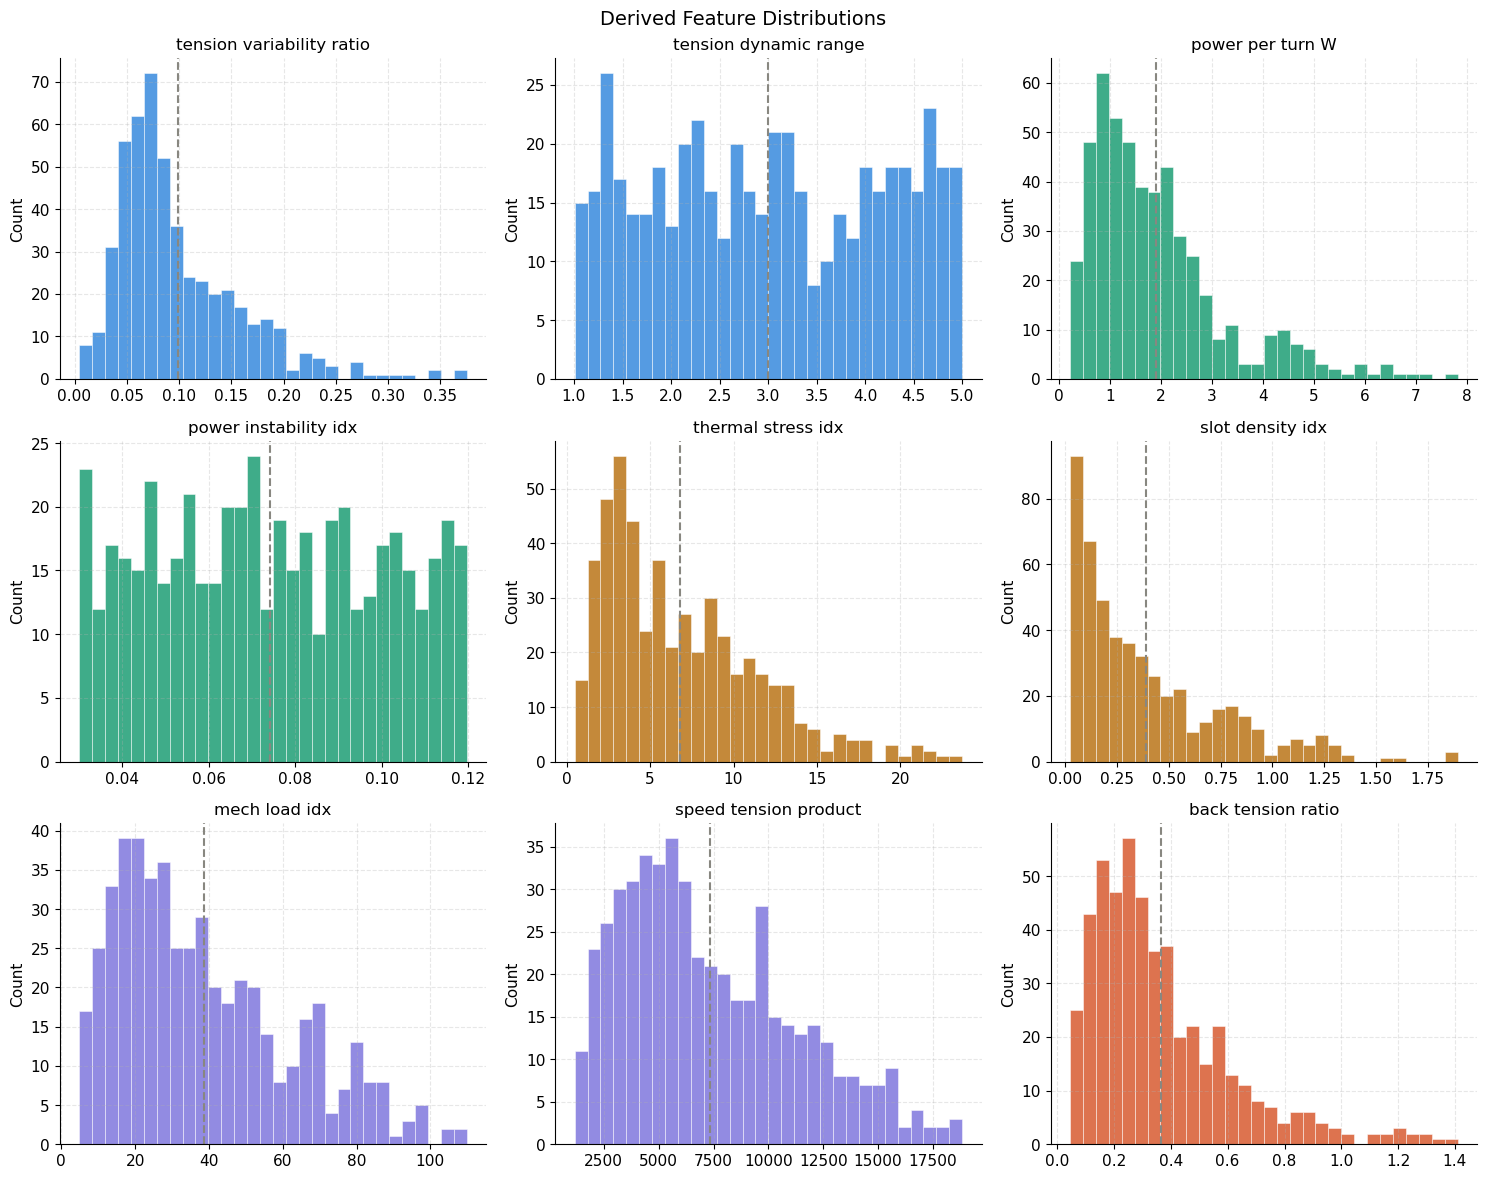

Saved: 09_derived_feature_distributions.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Derived Feature Distributions', fontsize=14, fontweight='500')
axes = axes.flatten()

colors = ['#378ADD', '#378ADD', '#1D9E75', '#1D9E75',
          '#BA7517', '#BA7517', '#7F77DD', '#7F77DD', '#D85A30']

for i, (feat, color) in enumerate(zip(DERIVED_FEATURES, colors)):
    axes[i].hist(fe[feat], bins=30, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].axvline(fe[feat].mean(), color='#888780', lw=1.5, linestyle='--')
    axes[i].set_title(feat.replace('_', ' '))
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/plots/09_derived_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_derived_feature_distributions.png")


### 3.2 Derived Feature Correlation with Targets

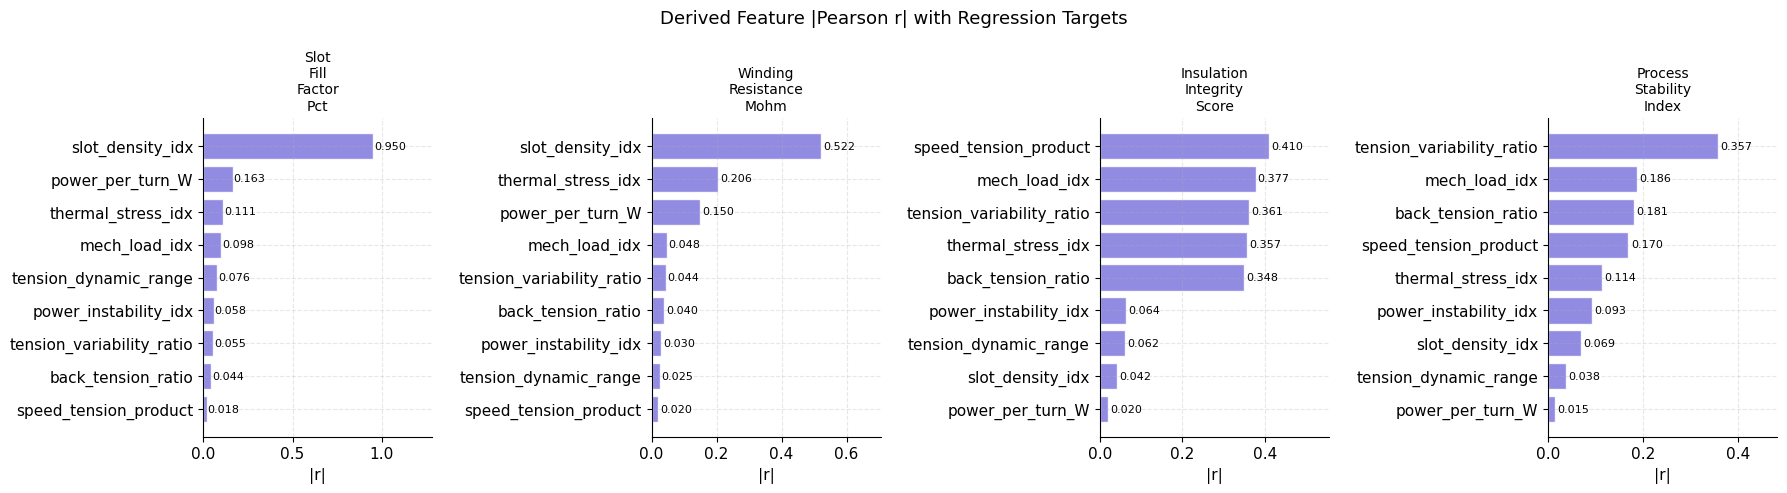

In [7]:
ALL_ENGINEERED = ALL_RAW_FEATURES + DERIVED_FEATURES

corr_derived = fe[DERIVED_FEATURES].corrwith

fig, axes = plt.subplots(1, len(TARGETS_REG), figsize=(18, 5))
fig.suptitle('Derived Feature |Pearson r| with Regression Targets', fontsize=13)

for ax, target in zip(axes, TARGETS_REG):
    corrs = fe[DERIVED_FEATURES].corrwith(fe[target]).abs().sort_values(ascending=True)
    ax.barh(corrs.index, corrs.values, color='#7F77DD', edgecolor='white', alpha=0.85)
    ax.set_title(target.replace('_','\n').title(), fontsize=10)
    ax.set_xlabel('|r|')
    ax.set_xlim(0, corrs.max() * 1.35)
    for i, (feat, val) in enumerate(corrs.items()):
        ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/10_derived_feature_target_corr.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Categorical Encoding — Coil Former Material

In [8]:
# One-hot encode coil_former_material (drop_first=False to keep all for interpretability)
material_dummies = pd.get_dummies(fe['coil_former_material'], prefix='material', dtype=int)
print("Dummy columns created:")
print(material_dummies.head(3).to_string())

fe = pd.concat([fe, material_dummies], axis=1)
MATERIAL_COLS = list(material_dummies.columns)
print(f"\nEncoded columns: {MATERIAL_COLS}")


Dummy columns created:
   material_Aluminum  material_Composite  material_Steel
0                  1                   0               0
1                  0                   0               1
2                  1                   0               0

Encoded columns: ['material_Aluminum', 'material_Composite', 'material_Steel']


## 5. Handle Log Transform for Skewed Features

In [9]:
# Check skewness of all features
numeric_feats = ALL_RAW_FEATURES + DERIVED_FEATURES
skewness = fe[numeric_feats].skew().abs().sort_values(ascending=False)
skewed = skewness[skewness > 1.0]

print(f"Features with |skew| > 1.0 ({len(skewed)} total):")
print(skewed.round(3).to_string())


Features with |skew| > 1.0 (9 total):
power_per_turn_W             1.501
tension_variability_ratio    1.487
back_tension_ratio           1.485
tension_slope_start          1.405
slot_density_idx             1.364
power_std_W                  1.231
tension_area_Nmm             1.171
temp_time_above_60s          1.068
thermal_stress_idx           1.017


In [10]:
# Log-transform highly skewed features (add small epsilon to handle zeros)
LOG_TRANSFORM_COLS = list(skewed.index)

for col in LOG_TRANSFORM_COLS:
    new_col = f'log_{col}'
    fe[new_col] = np.log1p(np.clip(fe[col], 0, None))

LOG_COLS = [f'log_{c}' for c in LOG_TRANSFORM_COLS]
print(f"Log-transformed {len(LOG_COLS)} features:")
for orig, log in zip(LOG_TRANSFORM_COLS, LOG_COLS):
    print(f"  {orig}  →  {log}  (skew: {fe[orig].skew():.2f} → {fe[log].skew():.2f})")


Log-transformed 9 features:
  power_per_turn_W  →  log_power_per_turn_W  (skew: 1.50 → 0.47)
  tension_variability_ratio  →  log_tension_variability_ratio  (skew: 1.49 → 1.29)
  back_tension_ratio  →  log_back_tension_ratio  (skew: 1.49 → 1.01)
  tension_slope_start  →  log_tension_slope_start  (skew: 1.40 → 0.17)
  slot_density_idx  →  log_slot_density_idx  (skew: 1.36 → 0.88)
  power_std_W  →  log_power_std_W  (skew: 1.23 → -0.12)
  tension_area_Nmm  →  log_tension_area_Nmm  (skew: 1.17 → -0.29)
  temp_time_above_60s  →  log_temp_time_above_60s  (skew: 1.07 → 0.36)
  thermal_stress_idx  →  log_thermal_stress_idx  (skew: 1.02 → -0.08)


## 6. Assemble Final Feature Matrix

In [11]:
# Build final feature list: raw + derived + log-transformed + material dummies
# Exclude: sample_id, coil_former_material (string), targets
FINAL_FEATURES = ALL_RAW_FEATURES + DERIVED_FEATURES + LOG_COLS + MATERIAL_COLS

# Remove duplicate base features that are now better represented by log versions
# Keep both raw and log for flexibility — models will select via importance
print(f"Final feature count : {len(FINAL_FEATURES)}")
print(f"Targets             : {len(TARGETS_ALL)}")
print(f"Total columns in df : {len(FINAL_FEATURES) + len(TARGETS_ALL) + 2}")  # +2 for id, material

X = fe[FINAL_FEATURES].copy()
y_reg = fe[TARGETS_REG].copy()
y_clf = fe[TARGET_CLF].copy()

print(f"\nX shape : {X.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"y_clf shape: {y_clf.shape}")
print(f"\nAny NaNs in X? {X.isna().any().any()}")
print(f"Any Infs in X? {np.isinf(X).any().any()}")


Final feature count : 44
Targets             : 5
Total columns in df : 51

X shape : (500, 44)
y_reg shape: (500, 4)
y_clf shape: (500,)

Any NaNs in X? False
Any Infs in X? False


## 7. Train / Validation / Test Split

In [12]:
# 70% train | 15% validation | 15% test
# Stratified on failure label to preserve class balance across splits

X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.15, random_state=SEED, stratify=y_clf
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_trainval, y_reg_trainval, y_clf_trainval,
    test_size=0.176, random_state=SEED, stratify=y_clf_trainval
)  # 0.176 of 0.85 ≈ 0.15 of full dataset

print("Split sizes:")
print(f"  Train      : {len(X_train):>4d}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation : {len(X_val):>4d}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test       : {len(X_test):>4d}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nFailure rate in each split:")
print(f"  Train      : {y_clf_train.mean()*100:.1f}%")
print(f"  Validation : {y_clf_val.mean()*100:.1f}%")
print(f"  Test       : {y_clf_test.mean()*100:.1f}%")


Split sizes:
  Train      :  350  (70.0%)
  Validation :   75  (15.0%)
  Test       :   75  (15.0%)

Failure rate in each split:
  Train      : 25.1%
  Validation : 25.3%
  Test       : 25.3%


## 8. Feature Scaling

In [13]:
# StandardScaler fitted ONLY on training data — prevents data leakage
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train),   columns=FINAL_FEATURES, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),     columns=FINAL_FEATURES, index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),    columns=FINAL_FEATURES, index=X_test.index)

print("Scaling applied. Sample means after scaling (should be ~0):")
print(X_train_scaled[PROCESS_PARAMS[:4]].mean().round(4).to_string())
print("\nSample stds after scaling (should be ~1):")
print(X_train_scaled[PROCESS_PARAMS[:4]].std().round(4).to_string())


Scaling applied. Sample means after scaling (should be ~0):
winding_speed_rpm   -0.0
wire_tension_N       0.0
wire_diameter_mm    -0.0
num_turns            0.0

Sample stds after scaling (should be ~1):
winding_speed_rpm    1.0014
wire_tension_N       1.0014
wire_diameter_mm     1.0014
num_turns            1.0014


### 8.1 Visualise Scaling Effect

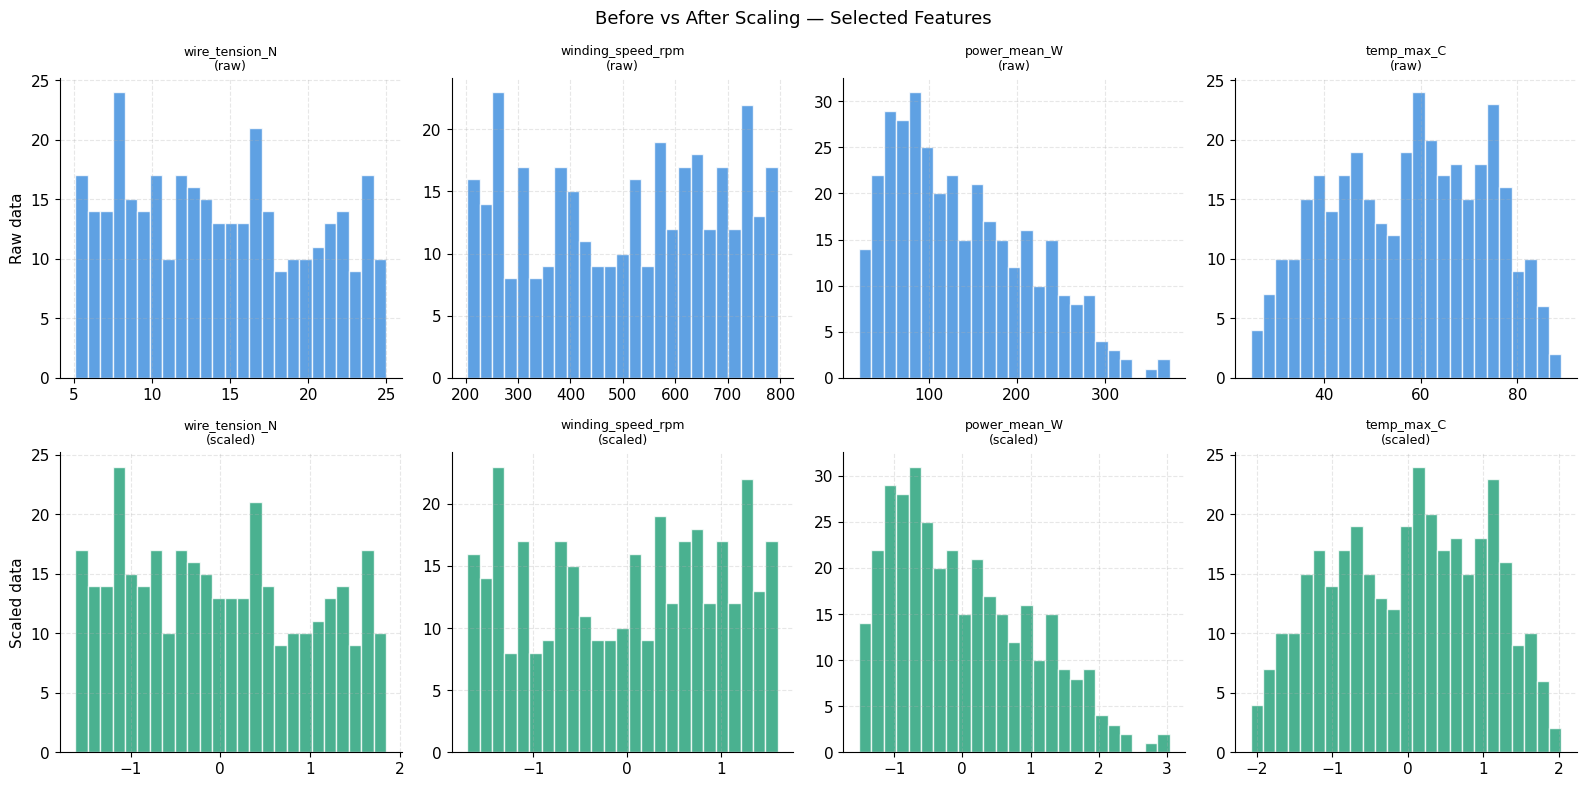

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Before vs After Scaling — Selected Features', fontsize=13)

sample_feats = ['wire_tension_N', 'winding_speed_rpm',
                'power_mean_W', 'temp_max_C']

for i, feat in enumerate(sample_feats):
    # Before
    axes[0, i].hist(X_train[feat], bins=25, color='#378ADD', alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f'{feat}\n(raw)', fontsize=9)
    # After
    axes[1, i].hist(X_train_scaled[feat], bins=25, color='#1D9E75', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(scaled)', fontsize=9)

axes[0, 0].set_ylabel('Raw data')
axes[1, 0].set_ylabel('Scaled data')
plt.tight_layout()
plt.savefig('../results/plots/11_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Save Processed Datasets

In [15]:
import joblib

# ── Save scaler for later use in inline_monitor ───────────────────────────
os.makedirs('../src', exist_ok=True)
joblib.dump(scaler, '../src/standard_scaler.pkl')
print("Scaler saved: ../src/standard_scaler.pkl")

# ── Save feature list ──────────────────────────────────────────────────────
with open('../src/feature_list.txt', 'w') as f:
    f.write('\n'.join(FINAL_FEATURES))
print(f"Feature list saved: {len(FINAL_FEATURES)} features")

# ── Save splits as CSV ─────────────────────────────────────────────────────
def save_split(X_raw, X_sc, y_r, y_c, tag):
    # Combine all into one dataframe for easy loading
    combined = X_sc.copy()
    for col in TARGETS_REG:
        combined[col] = y_r[col].values
    combined[TARGET_CLF] = y_c.values
    path = f'../data/processed/{tag}.csv'
    combined.to_csv(path, index=False)
    print(f"  Saved {tag}.csv  ({combined.shape})")

save_split(X_train, X_train_scaled, y_reg_train, y_clf_train, 'train')
save_split(X_val,   X_val_scaled,   y_reg_val,   y_clf_val,   'val')
save_split(X_test,  X_test_scaled,  y_reg_test,  y_clf_test,  'test')

# ── Also save unscaled full feature matrix (for tree models that don't need scaling) ──
X_full = fe[FINAL_FEATURES + TARGETS_ALL].copy()
X_full.to_csv('../data/processed/full_engineered.csv', index=False)
print(f"  Saved full_engineered.csv  ({X_full.shape})")


Scaler saved: ../src/standard_scaler.pkl
Feature list saved: 44 features
  Saved train.csv  ((350, 49))
  Saved val.csv  ((75, 49))
  Saved test.csv  ((75, 49))
  Saved full_engineered.csv  ((500, 49))


## 10. Feature Engineering Summary

In [17]:
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"  Raw features            : {len(ALL_RAW_FEATURES)}")
print(f"  Derived features        : {len(DERIVED_FEATURES)}")
print(f"  Log-transformed         : {len(LOG_COLS)}")
print(f"  Material dummy cols     : {len(MATERIAL_COLS)}")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL MODEL FEATURES    : {len(FINAL_FEATURES)}")
print()
print("NEW DERIVED FEATURES:")
descriptions = {
    'tension_variability_ratio' : 'tension_std / tension_mean — winding consistency',
    'tension_dynamic_range'     : 'tension_peak - tension_mean — tension spike magnitude',
    'power_per_turn_W'          : 'power_mean / num_turns — spindle effort per turn',
    'power_instability_idx'     : 'power_std / power_mean — power delivery stability',
    'thermal_stress_idx'        : 'temp_max × temp_gradient — insulation stress proxy',
    'slot_density_idx'          : '(n_turns × wire_cs) / slot_area — theoretical fill ratio',
    'mech_load_idx'             : 'wire_tension × spindle_torque — combined mechanical load',
    'speed_tension_product'     : 'rpm × tension — over-stress risk factor',
    'back_tension_ratio'        : 'back_tension / wire_tension — tension compensation ratio',
}
for k, v in descriptions.items():
    print(f"  {k:<30s} : {v}")
print()
print("DATA SPLITS:")
print(f"  Train      : {len(X_train)} samples  →  ../data/processed/train.csv")
print(f"  Validation : {len(X_val)} samples  →  ../data/processed/val.csv")
print(f"  Test       : {len(X_test)} samples  →  ../data/processed/test.csv")
print()
print("SAVED ARTEFACTS:")
print("  ../src/standard_scaler.pkl")
print("  ../src/feature_list.txt")
print()
print("NEXT STEP → 03_Regression.ipynb")


FEATURE ENGINEERING SUMMARY
  Raw features            : 23
  Derived features        : 9
  Log-transformed         : 9
  Material dummy cols     : 3
  ─────────────────────────────────────
  TOTAL MODEL FEATURES    : 44

NEW DERIVED FEATURES:
  tension_variability_ratio      : tension_std / tension_mean — winding consistency
  tension_dynamic_range          : tension_peak - tension_mean — tension spike magnitude
  power_per_turn_W               : power_mean / num_turns — spindle effort per turn
  power_instability_idx          : power_std / power_mean — power delivery stability
  thermal_stress_idx             : temp_max × temp_gradient — insulation stress proxy
  slot_density_idx               : (n_turns × wire_cs) / slot_area — theoretical fill ratio
  mech_load_idx                  : wire_tension × spindle_torque — combined mechanical load
  speed_tension_product          : rpm × tension — over-stress risk factor
  back_tension_ratio             : back_tension / wire_tension — tensi